# Imports:

In [161]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Datasets:

In [162]:
df_irregular = pd.read_csv("data/smell.csv")
df_regular = pd.read_csv("data/electricity.csv")

# Regular Dataset

Printing the head of the dataset

In [163]:
print(df_regular.head())

   date  day    period  nswprice  nswdemand  vicprice  vicdemand  transfer  \
0   0.0    2  0.000000  0.056443   0.439155  0.003467   0.422915  0.414912   
1   0.0    2  0.021277  0.051699   0.415055  0.003467   0.422915  0.414912   
2   0.0    2  0.042553  0.051489   0.385004  0.003467   0.422915  0.414912   
3   0.0    2  0.063830  0.045485   0.314639  0.003467   0.422915  0.414912   
4   0.0    2  0.085106  0.042482   0.251116  0.003467   0.422915  0.414912   

  class  
0    UP  
1    UP  
2    UP  
3    UP  
4  DOWN  


# Irregular Dataset

Printing the head of the dataset

In [164]:
print(df_irregular.head())

   epoch time                 date & time  smell value  skewed latitude  \
0  1577836610  01/01/2020 00:56:50 +01:00            3        40.557110   
1  1577850486  01/01/2020 04:48:06 +01:00            3        40.423138   
2  1577852394  01/01/2020 05:19:54 +01:00            3        40.381115   
3  1577857682  01/01/2020 06:48:02 +01:00            3        40.307728   
4  1577883411  01/01/2020 13:56:51 +01:00            3        40.307781   

   skewed longitude  zipcode                                smell description  \
0        -80.059578    15237  Sulfur. Hydrogen Sulfide.  Clairton Coke Works.   
1        -79.920387    15217                                       Industrial   
2        -79.860985    15110                                      Industrial    
3        -79.860908    15037                                us steel clairton   
4        -79.860908    15037                               u s steel clairton   

                         symptoms  \
0  Sore throat and lungs.

In [165]:
df_irregular['date & time'] = pd.to_datetime(df_irregular['date & time'], errors='coerce', utc=True)
df_irregular['date'] = df_irregular['date & time'].dt.date
df_irregular["year"] = df_irregular["date & time"].dt.year

## Visualizing the data

Different plots of the data, based on location and comments a day:

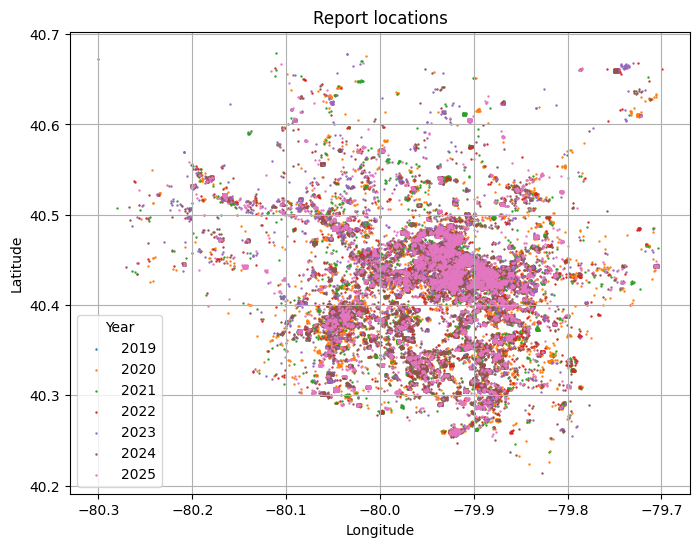

In [ ]:
plt.figure(figsize=(8,6))

for i in df_irregular["year"].dropna().unique():
    subset = df_irregular[df_irregular["year"] == i]
    
    plt.scatter(subset["skewed longitude"], subset["skewed latitude"], label=str(i), s=0.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Report locations")
plt.legend(title="Year")

plt.show()

C:\Users\thoma\AppData\Local\Temp\ipykernel_19048\1604739921.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  yearly["month"] = yearly["date & time"].dt.to_period("M")


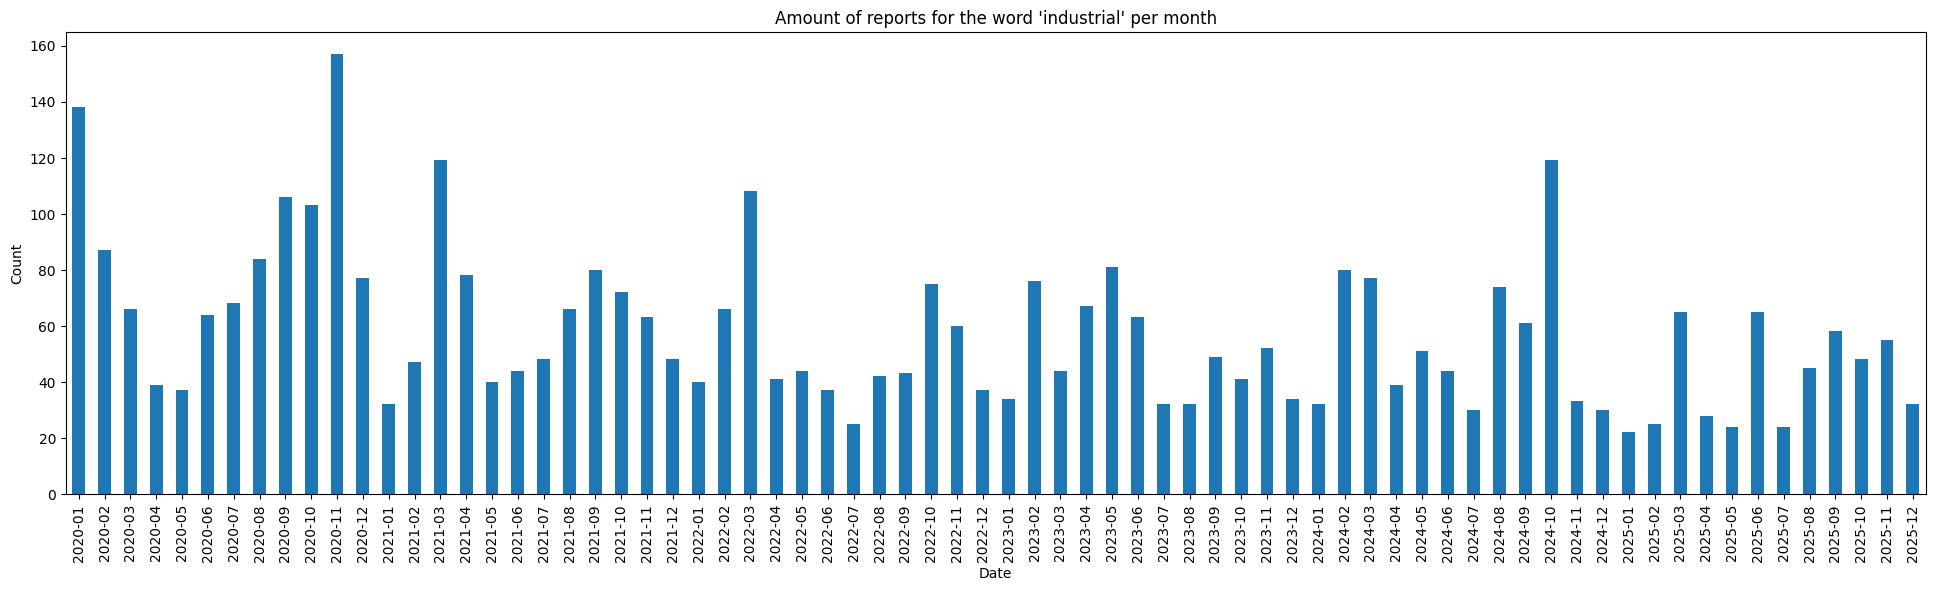

C:\Users\thoma\AppData\Local\Temp\ipykernel_19048\1604739921.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_irregular["month"] = df_irregular["date & time"].dt.to_period("M")


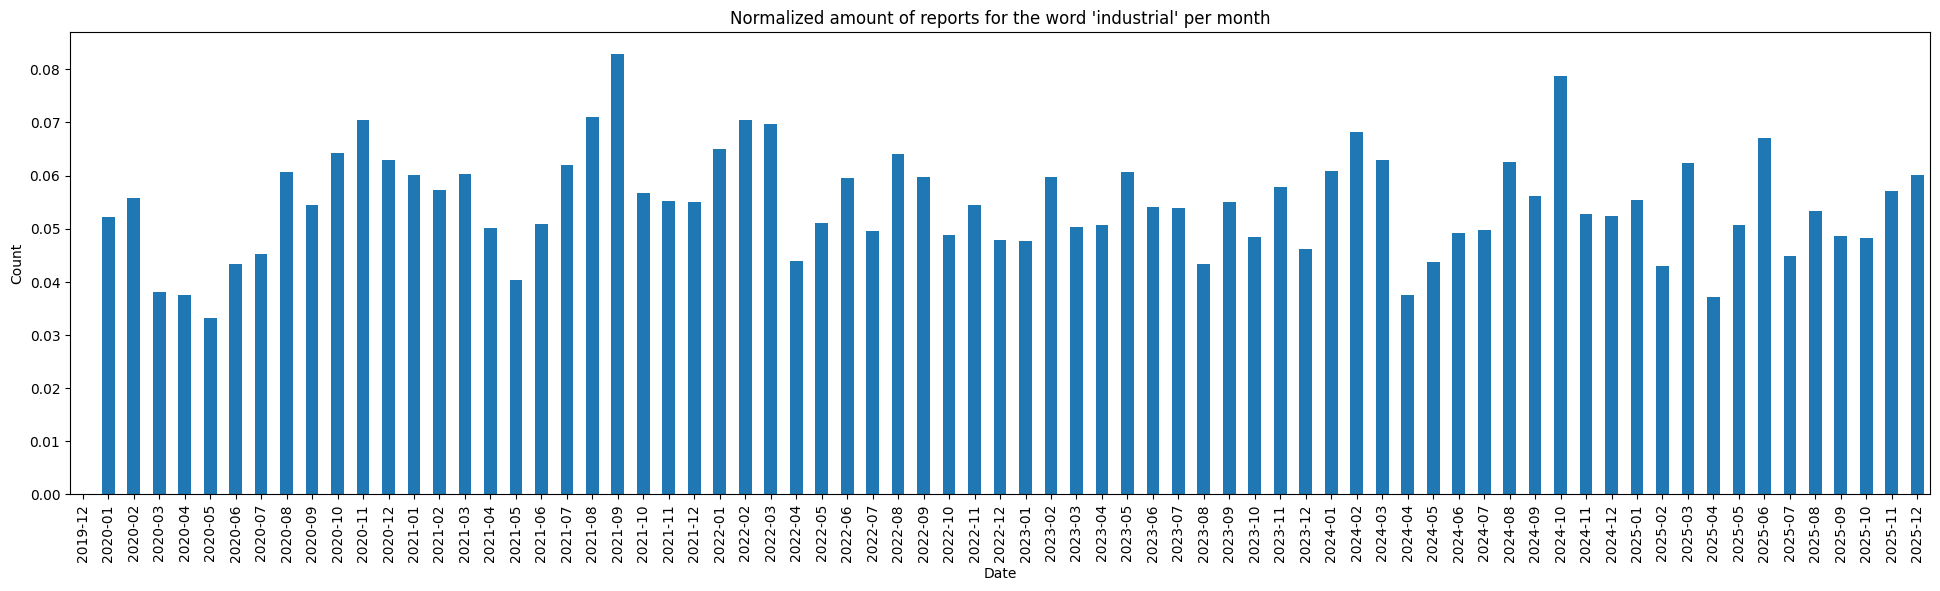

In [167]:
yearly = df_irregular[df_irregular["smell description"].str.contains("industrial", na=False)].copy()
yearly["month"] = yearly["date & time"].dt.to_period("M")

monthly = yearly.groupby("month").size()
monthly.plot(kind="bar", figsize=(24,6))

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Amount of reports for the word 'industrial' per month")

plt.show()


df_irregular["month"] = df_irregular["date & time"].dt.to_period("M")
total = df_irregular.groupby("month").size()

normalized = (monthly / total)
normalized.plot(kind="bar", figsize=(24,6))
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Normalized amount of reports for the word 'industrial' per month")

plt.show()

# Textual processing

The primarly method will be a TF-IDF. When the context given by this method is not sufficient we will use embeddings instead.

In [168]:
df_irregular["smell description"] = df_irregular["smell description"].str.lower()
df_irregular["symptoms"] = df_irregular["symptoms"].str.lower()
df_irregular["additional comments"] = df_irregular["additional comments"].str.lower()

<b>TF-IDF for smell description</b>:

In [169]:
tfidf_desc = TfidfVectorizer(stop_words="english", max_features=500)

X_desc = tfidf_desc.fit_transform(df_irregular["smell description"].fillna(""))

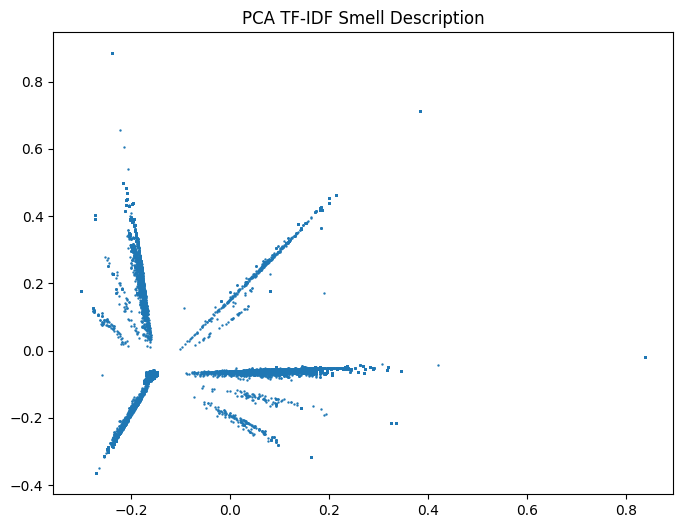

In [170]:
X_pca = PCA(n_components=2).fit_transform(X_desc.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Smell Description")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF for symptoms</b>:

In [171]:
tfidf_symptoms = TfidfVectorizer(stop_words="english", max_features=500)

X_symptoms = tfidf_symptoms.fit_transform(df_irregular["symptoms"].fillna(""))

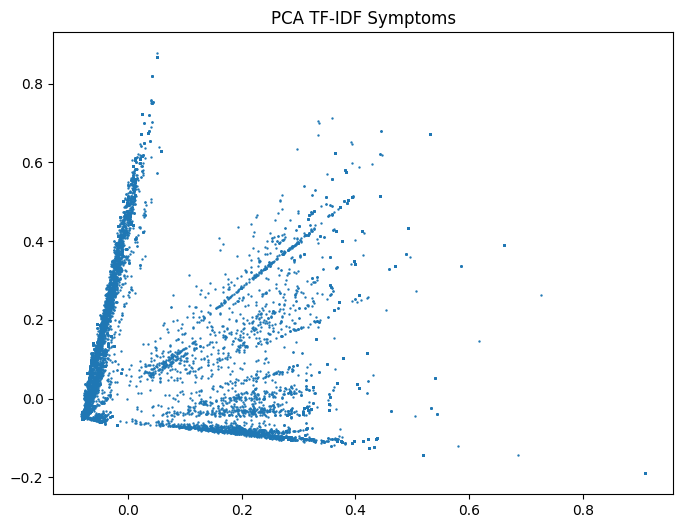

In [172]:
X_pca = PCA(n_components=2).fit_transform(X_symptoms.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Symptoms")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF for additional comments:</b>:

In [173]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_comments = tfidf_comments.fit_transform(df_irregular["additional comments"].fillna(""))

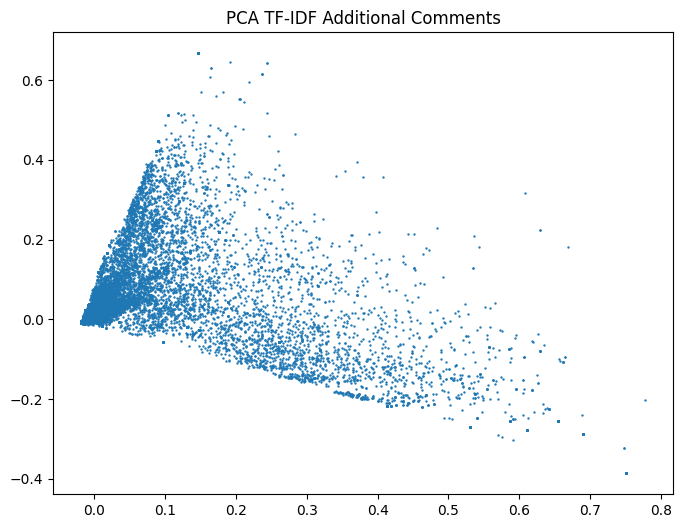

In [174]:
X_pca = PCA(n_components=2).fit_transform(X_comments.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Additional Comments")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)

<b>TF-IDF combined:</b>:

Combining the three text fields into one:

In [175]:
df_irregular["combined"] = df_irregular["smell description"].fillna("") + " " + df_irregular["symptoms"].fillna("") + " " + df_irregular["additional comments"].fillna("")

In [176]:
tfidf_comments = TfidfVectorizer(stop_words="english", max_features=500)

X_combined= tfidf_comments.fit_transform(df_irregular["combined"].fillna(""))

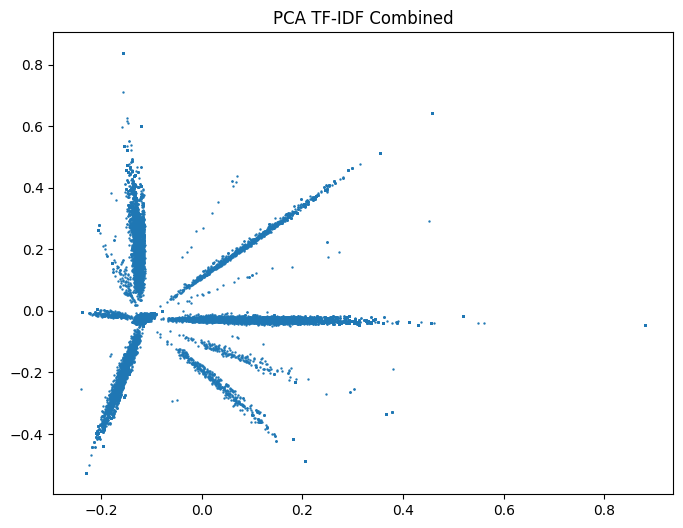

In [177]:
X_pca = PCA(n_components=2).fit_transform(X_combined.toarray())

plt.figure(figsize=(8,6))
plt.title("PCA TF-IDF Combined")
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=0.5)